# Práctica 1. Representación y medida de un qubit

**Asignatura:** Computación Cuántica  
**Tema 1:** Conceptos fundamentales. Superposición cuántica  
**Duración estimada:** 45-55 minutos  
**Modalidad:** Individual o por parejas

En esta práctica representaremos estados de un qubit mediante vectores complejos, comprobaremos su normalización, aplicaremos la regla de Born y simularemos medidas en la base computacional. No utilizaremos Qiskit: trabajaremos directamente con el formalismo matemático mediante NumPy.

## Objetivos

Al finalizar la práctica serás capaz de:

- Representar estados de un qubit como vectores complejos.
- Validar y normalizar vectores de estado.
- Calcular probabilidades mediante la regla de Born.
- Simular una o varias medidas en la base computacional.
- Comparar probabilidades teóricas y frecuencias experimentales.
- Analizar el efecto del número de *shots*.
- Identificar estados diferentes que producen el mismo histograma en una base concreta.

> Completa todas las celdas marcadas con `TODO` y responde en Markdown a las preguntas planteadas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEMILLA = 42
rng = np.random.default_rng(SEMILLA)

np.set_printoptions(precision=5, suppress=True)

## Parte A. Representación de estados

### Ejercicio 1. Base computacional

Representa los estados

$$|0\rangle=\begin{pmatrix}1\\0\end{pmatrix},\qquad |1\rangle=\begin{pmatrix}0\\1\end{pmatrix}.$$

Muestra los vectores, su forma, el tipo de sus componentes y su norma.

In [2]:
ket_0 = np.array([1, 0], dtype=complex)
ket_1 = np.array([0, 1], dtype=complex)

states = [ket_0, ket_1]

# --- OBTENER INFORMACIÓN DE UN ESTADO --- #
def getStateInfo(state):

        norm = np.linalg.norm(state)

        print("Para el elemento.", state)
        print("Forma: ", state.shape)
        print("DType: ", state.dtype)
        print("Amplitudes: alpha =", state[0], "| beta =", state[1])
        print("Norma:", norm)
        print("Normalizado: ", np.isclose(norm, 1.0, atol=1e-10), "\n")

# --- OBTENER INFORMACIÓN DE VARIOS ESTADOS --- #
def getStatesInfo(states):

        if isinstance(states, dict):
                for key, value in states.items():
                        getStateInfo(value)

        else:
                for state in states:
                        getStateInfo(state)
                        

getStatesInfo(states)

Para el elemento. [1.+0.j 0.+0.j]
Forma:  (2,)
DType:  complex128
Amplitudes: alpha = (1+0j) | beta = 0j
Norma: 1.0
Normalizado:  True 

Para el elemento. [0.+0.j 1.+0.j]
Forma:  (2,)
DType:  complex128
Amplitudes: alpha = 0j | beta = (1+0j)
Norma: 1.0
Normalizado:  True 



**Responde:**

1. ¿Por qué los arrays deben admitir números complejos?

Por que cuando trabajamos con estados cuánticos, se deben de admitir valores complejos para los valores de las amplitudes.

2. ¿Qué dimensión tiene el espacio de estados de un qubit?

Para este caso, los estados están formados por dos vectores, lo que le da una dimensión de 2. Es decir, es un array con dos elementos.

3. ¿Qué valor debe tener la norma de un estado válido?

Debe de estar normalizado a 1. Es decir, la probabilidad total sea 1.


### Ejercicio 2. Superposiciones

Representa los siguientes estados y, para cada uno, muestra el vector, sus amplitudes, su norma y si está normalizado:

$$|\psi_1\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}}$$

$$|\psi_2\rangle=\frac{\sqrt{3}}{2}|0\rangle+\frac{1}{2}|1\rangle$$

$$|\psi_3\rangle=\frac{1}{\sqrt{2}}|0\rangle+\frac{i}{\sqrt{2}}|1\rangle$$

$$|\psi_4\rangle=\frac{1+i}{2}|0\rangle+\frac{1-i}{2}|1\rangle.$$

In [3]:
psi_1 = np.array([1 / np.sqrt(2), 1 / np.sqrt(2)], dtype=complex)
psi_2 = np.array([np.sqrt(3) / 2, 1 / 2], dtype=complex)
psi_3 = np.array([1 / np.sqrt(2), 1j / np.sqrt(2)], dtype=complex)
psi_4 = np.array([(1 + 1j) / 2, (1 - 1j) / 2], dtype=complex)

states = {
    "psi_1": psi_1,
    "psi_2": psi_2,
    "psi_3": psi_3,
    "psi_4": psi_4,
}

getStatesInfo(states)

Para el elemento. [0.70711+0.j 0.70711+0.j]
Forma:  (2,)
DType:  complex128
Amplitudes: alpha = (0.7071067811865475+0j) | beta = (0.7071067811865475+0j)
Norma: 0.9999999999999999
Normalizado:  True 

Para el elemento. [0.86603+0.j 0.5    +0.j]
Forma:  (2,)
DType:  complex128
Amplitudes: alpha = (0.8660254037844386+0j) | beta = (0.5+0j)
Norma: 0.9999999999999999
Normalizado:  True 

Para el elemento. [0.70711+0.j      0.     +0.70711j]
Forma:  (2,)
DType:  complex128
Amplitudes: alpha = (0.7071067811865475+0j) | beta = 0.7071067811865475j
Norma: 0.9999999999999999
Normalizado:  True 

Para el elemento. [0.5+0.5j 0.5-0.5j]
Forma:  (2,)
DType:  complex128
Amplitudes: alpha = (0.5+0.5j) | beta = (0.5-0.5j)
Norma: 1.0
Normalizado:  True 



**Responde:**

1. ¿Por qué no conviene comprobar números en coma flotante con `valor == 1.0`?

Por problemas de la precisión de los números en coma flotante, las operaciones nos pueden dar números cercanos a 1 pero que no lo sean exactamente. Tenemos que blindarnos ante esta posibilidad.

2. ¿Puede un estado válido contener amplitudes imaginarias?

Si, siempre y cuando al evaluarse por su conjugado (el cuadrado del imaginario) solo resulte en números reales. En el caso de que no lo sea estariamos ante un estado no válido.

3. ¿Implica una amplitud imaginaria que la probabilidad sea imaginaria?

No, al elevar un imaginario como -i al cuadrado, nos queda 1. El valor de la amplitud sería imaginario pero su cuadrado (la probabilidad) sería un número real.

## Parte B. Validación y normalización

### Ejercicio 3. Validación de estados

Completa una función que verifique que la entrada tiene dos amplitudes, contiene valores finitos y posee norma uno. El vector nulo y los vectores con otra dimensión no son estados válidos de un qubit.

In [4]:
# --- VALIDAR UN ESTADO --- #
def isValidState(estado, tolerancia=1e-10, checkNorm=True):

    # Transformamos el estado.
    try:
        # Forzamos el tipo array.
        vector = np.asarray(estado, dtype=complex)

        if(vector.shape != (2,)): return False, "El estado debe de ser un ket."

        if not np.all(np.isfinite(vector)): return False, "El estado contiene valores infinitos o NaN"

        norm = np.linalg.norm(vector)
        if(np.isclose(norm, 0.0, atol=tolerancia)): return False, "El estado es el vector nulo"

        # Solo comprobamos la norma si se pide (normalizeState necesita aceptar estados sin normalizar).
        if(checkNorm and not np.isclose(norm, 1.0, atol=tolerancia)): return False, "El estado no está normalizado"

        return True, "El estado es válido"

    except(ValueError, TypeError):
        return False, "El estado no se puede convertir a un array de complejos"

# --- COMPROBAR SI UN ESTADO ESTÁ NORMALIZADO --- #
def isNormalizedState(estado, tolerancia=1e-10):

    isValid, message = isValidState(estado, tolerancia, checkNorm=False)
    if(not isValid): return False

    norm = np.linalg.norm(np.asarray(estado, dtype=complex))
    return bool(np.isclose(norm, 1.0, atol=tolerancia))


casos = {
    "ket_0": [1, 0],
    "ket_1": [0, 1],
    "equilibrado": [1 / np.sqrt(2), 1 / np.sqrt(2)],
    "no_normalizado": [1, 1],
    "vector_nulo": [0, 0],
    "dimension_incorrecta": [1, 0, 0],
    "con_nan": [np.nan, 0],
}

for caso in casos:
    print(f"Validez del caso: {caso:<25} ({casos[caso]}): {isValidState(casos[caso])}")

Validez del caso: ket_0                     ([1, 0]): (True, 'El estado es válido')
Validez del caso: ket_1                     ([0, 1]): (True, 'El estado es válido')
Validez del caso: equilibrado               ([np.float64(0.7071067811865475), np.float64(0.7071067811865475)]): (True, 'El estado es válido')
Validez del caso: no_normalizado            ([1, 1]): (False, 'El estado no está normalizado')
Validez del caso: vector_nulo               ([0, 0]): (False, 'El estado es el vector nulo')
Validez del caso: dimension_incorrecta      ([1, 0, 0]): (False, 'El estado debe de ser un ket.')
Validez del caso: con_nan                   ([nan, 0]): (False, 'El estado contiene valores infinitos o NaN')


### Ejercicio 4. Normalización

Completa la función. Debe convertir la entrada a un array complejo, comprobar su dimensión y finitud, rechazar el vector nulo y devolver un vector de norma uno.

In [5]:
# --- NORMALIZAR UN ESTADO --- #
def normalizeState(estado, tolerancia=1e-10):

    # Comprobamos dimensión, finitud y que no sea el vector nulo (sin exigir norma 1).
    isValid, message = isValidState(estado, tolerancia, checkNorm=False)
    if(not isValid): return False, message

    vector = np.asarray(estado, dtype=complex)

    # Si ya estaba normalizado lo devolvemos tal cual.
    if(isNormalizedState(vector, tolerancia)): return True, vector

    else:
        norm = np.linalg.norm(vector)
        return True, vector / norm

vectores = [
    np.array([1, 1], dtype=complex),
    np.array([3, 4], dtype=complex),
    np.array([1 + 1j, 2 - 1j], dtype=complex),
    np.array([0, 0], dtype=complex),
]

for vector in vectores:
    isNormalized, normalizado = normalizeState(vector)
    print(f"Caso normalizado: ({vector}): {normalizado}")

Caso normalizado: ([1.+0.j 1.+0.j]): [0.70711+0.j 0.70711+0.j]
Caso normalizado: ([3.+0.j 4.+0.j]): [0.6+0.j 0.8+0.j]
Caso normalizado: ([1.+1.j 2.-1.j]): [0.37796+0.37796j 0.75593-0.37796j]
Caso normalizado: ([0.+0.j 0.+0.j]): El estado es el vector nulo


**Responde:**

1. ¿Cambia la dirección del vector al normalizarlo?

No, solo cambia su magnitud.

2. ¿Qué ocurre con la relación entre sus componentes?

Los valores se mantienen proporcionalmente con la misma diferencia de valores, es decir, con respecto a 1 tienen la misma "importancia" y la misma información. Solo se asegura que trabajemos con una probabilidad total válida, es decir, de 1 como máximo.

3. ¿Por qué no puede normalizarse el vector nulo?

Por un problema de división entre 0. La norma del vector nulo es 0 y para normalizar tenemos que dividir entre ella.

## Parte C. Regla de Born

### Ejercicio 5. Probabilidades de medida

Para $|\psi\rangle=\alpha|0\rangle+\beta|1\rangle$, la regla de Born establece $P(0)=|\alpha|^2$ y $P(1)=|\beta|^2$. Completa la función sin utilizar `estado ** 2`.

In [6]:
# --- PROBABILIDADES DE MEDIDA (REGLA DE BORN) --- #
def calculateProbs(estado):

    isNormalized, result_norm = normalizeState(estado)

    if(not isNormalized): return False, "El estado no es normalizable"

    arrays = []
    for element in result_norm:
        arrays.append(float(np.abs(element)**2))
    return True, arrays

### Ejercicio 6. Cálculo manual con amplitudes complejas

Considera

$$|\psi\rangle=\frac{1+i}{2}|0\rangle+\frac{1-i}{2}|1\rangle.$$

Calcula manualmente $\alpha$, $\beta$, $|\alpha|^2$, $|\beta|^2$, $P(0)$ y $P(1)$. Después compruébalo con la función anterior.

**Desarrollo y respuesta:**

Las amplitudes son $\alpha=\frac{1+i}{2}$ y $\beta=\frac{1-i}{2}$.

Para calcular el módulo al cuadrado multiplicamos cada amplitud por su conjugado:

$$|\alpha|^2=\alpha\,\alpha^*=\frac{(1+i)(1-i)}{4}=\frac{1-i^2}{4}=\frac{1+1}{4}=\frac{1}{2}$$

$$|\beta|^2=\beta\,\beta^*=\frac{(1-i)(1+i)}{4}=\frac{1-i^2}{4}=\frac{1+1}{4}=\frac{1}{2}$$

Por la regla de Born, $P(0)=|\alpha|^2=0{,}5$ y $P(1)=|\beta|^2=0{,}5$. Comprobamos que el estado está normalizado, ya que $P(0)+P(1)=0{,}5+0{,}5=1$.

In [7]:
# --- COMPROBACIÓN DEL EJERCICIO 6 --- #
state = np.array([(1 + 1j) / 2, (1 - 1j) / 2], dtype=complex)
calculateProbs(state)

(True, [0.5000000000000001, 0.5000000000000001])

## Parte D. Simulación de la medida

### Ejercicio 7. Una medida

Completa la función para simular una medida en la base computacional. Debe devolver el entero 0 o 1 de acuerdo con las probabilidades del estado.

In [8]:
# --- SIMULAR UNA MEDIDA --- #
def measure(state, rng=None):
    """Simula una medida del qubit en la base computacional."""

    # Si no nos pasan generador, creamos uno con la semilla por defecto.
    if(rng is None): rng = np.random.default_rng(SEMILLA)

    isValid, probabilities = calculateProbs(state)
    if(not isValid): return False, "ERROR: Se ha introducido un estado no válido"

    return int(rng.choice([0, 1], p=probabilities))


# --- MEDIR ket_0, ket_1, psi_1 Y psi_2 --- #
medidas = {
    "ket_0": ket_0,
    "ket_1": ket_1,
    "psi_1": psi_1,
    "psi_2": psi_2,
}

for nombre in medidas:
    print(f"Medida de {nombre:<6}: {measure(medidas[nombre], rng)}")

Medida de ket_0 : 0
Medida de ket_1 : 1
Medida de psi_1 : 1
Medida de psi_2 : 0


**Responde:**

1. ¿Qué debe producir siempre $|0\rangle$? ¿Y $|1\rangle$?

El estado $|0\rangle$ debe producir siempre un 0, ya que su probabilidad es $P(0)=1$. De la misma forma, $|1\rangle$ debe producir siempre un 1, porque $P(1)=1$.

2. ¿Permite una medida aislada conocer $\alpha$ y $\beta$?

No, una medida aislada solo nos devuelve un 0 o un 1. Las amplitudes son números complejos y no se pueden recuperar con un único bit de información. Con muchas medidas solo podríamos estimar $|\alpha|^2$ y $|\beta|^2$.

3. Si obtenemos 0, ¿podemos afirmar que el estado inicial era $|0\rangle$?

No, obtener un 0 solo nos dice que $\alpha \neq 0$. Por ejemplo, $|\psi_1\rangle$ también da 0 con probabilidad 0,5, y $|\psi_2\rangle$ con probabilidad 0,75.

### Ejercicio 8. Medidas repetidas

Cada *shot* representa una nueva preparación del mismo estado seguida de una medida. La función debe rechazar valores de `shots` que no sean enteros positivos.

In [9]:
# --- MEDIDAS REPETIDAS --- #
def recursiveMeasure(estado, shots=1000, semilla=None):

    # Los shots deben ser un entero positivo (bool es subclase de int, así que lo descartamos).
    if(isinstance(shots, bool) or not isinstance(shots, (int, np.integer)) or shots <= 0):
        return False, "ERROR: Los shots deben de ser un entero positivo"

    # Si no nos pasan semilla, usamos la de por defecto.
    if(semilla is None): semilla = SEMILLA
    rng = np.random.default_rng(semilla)

    isValid, probabilities = calculateProbs(estado)
    if(not isValid): return False, "ERROR: Se ha introducido un estado no válido"

    samples = rng.choice([0, 1], size=shots, p=probabilities)
    count = np.bincount(samples, minlength=2)
    return {0: int(count[0]), 1: int(count[1])}


shots_estudiados = [10, 100, 1_000, 10_000, 100_000]
resultados_experimento = []

# Probabilidades teóricas de psi_2 (P(0) = 0.75).
isValid, probs_teoricas = calculateProbs(psi_2)

for i, shot in enumerate(shots_estudiados):
    resultados_experimento.append(recursiveMeasure(psi_2, shot, SEMILLA + i))

# --- TABLA DE RESULTADOS --- #
for shot, resultado in zip(shots_estudiados, resultados_experimento):

    f_0 = resultado[0] / shot
    f_1 = resultado[1] / shot
    E_0 = abs(f_0 - probs_teoricas[0])
    E_1 = abs(f_1 - probs_teoricas[1])

    print(f"Shots: {shot:>7} | N(0): {resultado[0]:>6} | N(1): {resultado[1]:>6} | f(0): {f_0:.5f} | f(1): {f_1:.5f} | E_0: {E_0:.5f} | E_1: {E_1:.5f}")

Shots:      10 | N(0):      5 | N(1):      5 | f(0): 0.50000 | f(1): 0.50000 | E_0: 0.25000 | E_1: 0.25000
Shots:     100 | N(0):     75 | N(1):     25 | f(0): 0.75000 | f(1): 0.25000 | E_0: 0.00000 | E_1: 0.00000
Shots:    1000 | N(0):    760 | N(1):    240 | f(0): 0.76000 | f(1): 0.24000 | E_0: 0.01000 | E_1: 0.01000
Shots:   10000 | N(0):   7509 | N(1):   2491 | f(0): 0.75090 | f(1): 0.24910 | E_0: 0.00090 | E_1: 0.00090
Shots:  100000 | N(0):  74920 | N(1):  25080 | f(0): 0.74920 | f(1): 0.25080 | E_0: 0.00080 | E_1: 0.00080


Completa la tabla con tus resultados:

| Shots | $N(0)$ | $N(1)$ | $f(0)$ | $f(1)$ | $E_0$ | $E_1$ |
|---:|---:|---:|---:|---:|---:|---:|
| 10 | 5 | 5 | 0,5000 | 0,5000 | 0,2500 | 0,2500 |
| 100 | 75 | 25 | 0,7500 | 0,2500 | 0,0000 | 0,0000 |
| 1.000 | 760 | 240 | 0,7600 | 0,2400 | 0,0100 | 0,0100 |
| 10.000 | 7.509 | 2.491 | 0,7509 | 0,2491 | 0,0009 | 0,0009 |
| 100.000 | 74.920 | 25.080 | 0,7492 | 0,2508 | 0,0008 | 0,0008 |

**Responde:** ¿Coinciden exactamente frecuencias y probabilidades? ¿Qué ocurre al aumentar los shots? ¿Debe disminuir el error de forma estrictamente monótona? ¿Se mide repetidamente el mismo qubit después de su colapso?

**Respuesta:** (Tomamos $|\psi_2\rangle$, con $P(0)=0{,}75$ y $P(1)=0{,}25$, y el error como $E_i=|f(i)-P(i)|$.)

No, las frecuencias y las probabilidades no coinciden exactamente, salvo por casualidad (como con 100 shots, donde $f(0)=0{,}75$). Al aumentar los shots las frecuencias se acercan a las probabilidades teóricas, y el error pasa de $0{,}25$ con 10 shots a $0{,}0008$ con 100.000.

Sin embargo, el error no tiene por qué disminuir de forma estrictamente monótona, ya que cada experimento es aleatorio. En nuestra tabla, con 100 shots el error es 0 y con 1.000 shots sube a 0,01. Lo que disminuye es el error esperado, no el de cada experimento concreto.

Y no, no se mide repetidamente el mismo qubit. Cada shot es una nueva preparación del mismo estado, ya que después de medir el qubit colapsa y volver a medirlo daría siempre el mismo resultado.

## Parte E. Visualización

### Ejercicio 9. Convergencia de la frecuencia

Representa la frecuencia experimental de obtener 0 frente al número de shots. Añade una línea horizontal para la probabilidad teórica $P(0)=0{,}75$ y usa escala logarítmica en el eje horizontal. Incluye título, etiquetas, leyenda y cuadrícula.

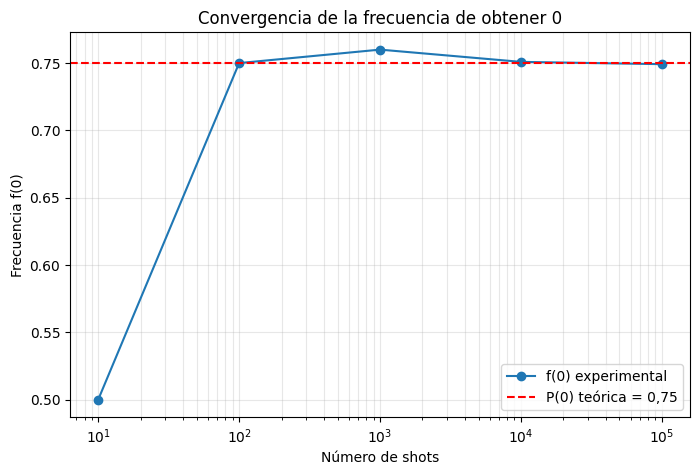

In [10]:
# --- CONVERGENCIA DE LA FRECUENCIA f(0) --- #
frecuencias_0 = []
for shot, resultado in zip(shots_estudiados, resultados_experimento):
    frecuencias_0.append(resultado[0] / shot)

plt.figure(figsize=(8, 5))
plt.plot(shots_estudiados, frecuencias_0, marker="o", label="f(0) experimental")
plt.axhline(0.75, color="red", linestyle="--", label="P(0) teórica = 0,75")
plt.xscale("log")
plt.title("Convergencia de la frecuencia de obtener 0")
plt.xlabel("Número de shots")
plt.ylabel("Frecuencia f(0)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

**Interpretación de la gráfica (4-6 líneas):**

Con pocos shots la frecuencia experimental está lejos de la probabilidad teórica (con 10 shots obtenemos $f(0)=0{,}5$ frente a $0{,}75$). A medida que aumentamos los shots la curva se acerca a la línea roja, y a partir de 1.000 shots queda prácticamente sobre ella. No es una convergencia monótona: con 100 shots coincide exactamente con $0{,}75$ y con 1.000 se separa un poco, por el carácter aleatorio de las medidas. La escala logarítmica nos permite ver bien el comportamiento al aumentar los shots en órdenes de magnitud.

### Ejercicio 10. Histograma de resultados

Para 1.000 shots, representa un diagrama de barras con los conteos de 0 y 1. Añade el valor numérico sobre cada barra.

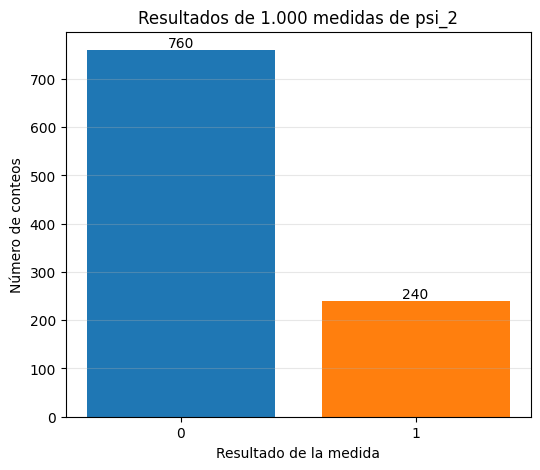

In [11]:
# --- HISTOGRAMA DE CONTEOS (1000 SHOTS) --- #
conteos = resultados_experimento[shots_estudiados.index(1_000)]

plt.figure(figsize=(6, 5))
barras = plt.bar(["0", "1"], [conteos[0], conteos[1]], color=["tab:blue", "tab:orange"])
plt.bar_label(barras)
plt.title("Resultados de 1.000 medidas de psi_2")
plt.xlabel("Resultado de la medida")
plt.ylabel("Número de conteos")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

**Responde:**

1. ¿Qué información muestra el histograma?

Muestra cuántas veces hemos obtenido cada resultado (0 o 1) en las medidas, es decir, la distribución de frecuencias en la base computacional. Con ella podemos estimar las probabilidades de cada resultado.

2. ¿Muestra directamente las amplitudes?

No, solo muestra los conteos. A partir de ellos podemos estimar $|\alpha|^2$ y $|\beta|^2$, y por tanto el módulo de las amplitudes, pero no las amplitudes en sí (que son números complejos).

3. ¿Permite determinar la fase relativa?

No, la fase relativa no afecta a las probabilidades en la base computacional, así que no aparece en el histograma.

## Parte F. Estados con las mismas probabilidades

### Ejercicio 11. El papel de la fase

Compara los estados

$$|\psi_A\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}},\qquad |\psi_B\rangle=\frac{|0\rangle-|1\rangle}{\sqrt{2}},\qquad |\psi_C\rangle=\frac{|0\rangle+i|1\rangle}{\sqrt{2}}.$$

Represéntalos, valida su normalización, calcula sus probabilidades y simula 10.000 medidas de cada uno.

Para el elemento. [0.70711+0.j 0.70711+0.j]
Forma:  (2,)
DType:  complex128
Amplitudes: alpha = (0.7071067811865475+0j) | beta = (0.7071067811865475+0j)
Norma: 0.9999999999999999
Normalizado:  True 

Para el elemento. [ 0.70711+0.j -0.70711+0.j]
Forma:  (2,)
DType:  complex128
Amplitudes: alpha = (0.7071067811865475+0j) | beta = (-0.7071067811865475+0j)
Norma: 0.9999999999999999
Normalizado:  True 

Para el elemento. [0.70711+0.j      0.     +0.70711j]
Forma:  (2,)
DType:  complex128
Amplitudes: alpha = (0.7071067811865475+0j) | beta = 0.7071067811865475j
Norma: 0.9999999999999999
Normalizado:  True 

psi_A: P(0) = 0.50000 | P(1) = 0.50000 | N(0) = 5015 | N(1) = 4985
psi_B: P(0) = 0.50000 | P(1) = 0.50000 | N(0) = 4953 | N(1) = 5047
psi_C: P(0) = 0.50000 | P(1) = 0.50000 | N(0) = 5028 | N(1) = 4972


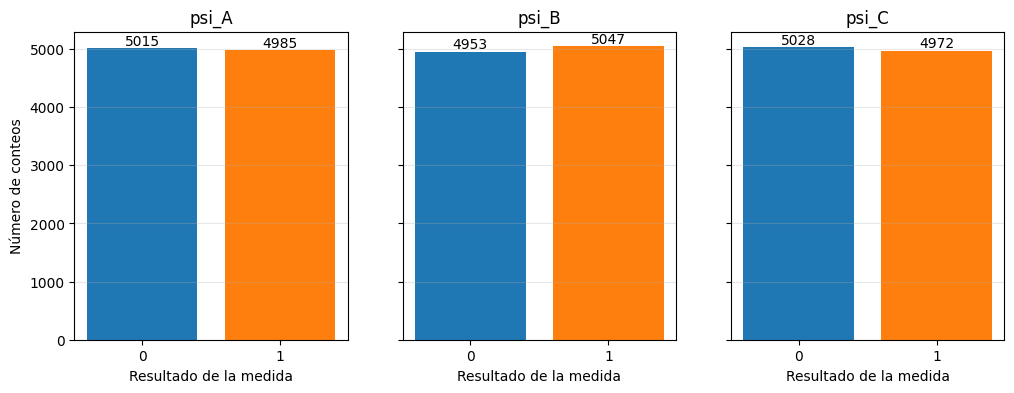

In [12]:
# --- ESTADOS CON LAS MISMAS PROBABILIDADES --- #
psi_A = np.array([1 / np.sqrt(2), 1 / np.sqrt(2)], dtype=complex)
psi_B = np.array([1 / np.sqrt(2), -1 / np.sqrt(2)], dtype=complex)
psi_C = np.array([1 / np.sqrt(2), 1j / np.sqrt(2)], dtype=complex)

states = {
    "psi_A": psi_A,
    "psi_B": psi_B,
    "psi_C": psi_C,
}

# Validamos la normalización de cada estado.
getStatesInfo(states)

# Probabilidades y simulación de 10.000 medidas de cada estado.
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, (nombre, estado), i in zip(axes, states.items(), range(len(states))):

    isValid, probs = calculateProbs(estado)
    conteos = recursiveMeasure(estado, 10_000, SEMILLA + i)

    print(f"{nombre}: P(0) = {probs[0]:.5f} | P(1) = {probs[1]:.5f} | N(0) = {conteos[0]} | N(1) = {conteos[1]}")

    barras = ax.bar(["0", "1"], [conteos[0], conteos[1]], color=["tab:blue", "tab:orange"])
    ax.bar_label(barras)
    ax.set_title(nombre)
    ax.set_xlabel("Resultado de la medida")
    ax.grid(True, axis="y", alpha=0.3)

axes[0].set_ylabel("Número de conteos")
plt.show()

**Responde:**

1. ¿Son iguales los tres vectores?

No, los tres vectores son distintos: $|\psi_A\rangle$ tiene las dos amplitudes iguales, $|\psi_B\rangle$ tiene la segunda con signo negativo y $|\psi_C\rangle$ tiene la segunda multiplicada por $i$.

2. ¿Producen las mismas probabilidades en la base computacional?

Si, en los tres casos $|\alpha|^2=|\beta|^2=\frac{1}{2}$, ya que $|1|^2=|-1|^2=|i|^2=1$. Los tres dan $P(0)=P(1)=0{,}5$.

3. ¿Podemos concluir que representan el mismo estado?

No, tener las mismas probabilidades en una base no implica que sea el mismo estado. Se diferencian en la fase relativa entre las amplitudes de $|0\rangle$ y $|1\rangle$, por lo que son estados distintos.

4. ¿Permite esta medida detectar sus diferencias?

No, al medir en la base computacional solo accedemos a los módulos al cuadrado de las amplitudes, y la fase relativa no influye en ellos.

5. ¿Qué información no aparece en los histogramas?

La fase relativa entre las amplitudes (el signo o el factor $i$). Los histogramas son prácticamente iguales, y las pequeñas diferencias de conteos se deben solo al azar.

6. ¿Qué fenómeno permitirá aprovechar posteriormente estas diferencias?

La interferencia cuántica. Al aplicar puertas que mezclen las amplitudes (o al medir en otra base), la fase relativa cambia las probabilidades finales y entonces sí se pueden distinguir.

### Ejercicio 12. Fase global y fase relativa

Compara

$$|\phi_A\rangle=\frac{1}{\sqrt{2}}\begin{pmatrix}1\\1\end{pmatrix},\quad |\phi_B\rangle=-\frac{1}{\sqrt{2}}\begin{pmatrix}1\\1\end{pmatrix},\quad |\phi_C\rangle=\frac{1}{\sqrt{2}}\begin{pmatrix}1\\-1\end{pmatrix}.$$

¿Qué estados se diferencian solo por una fase global? ¿Dónde hay una diferencia de fase relativa? ¿Cuáles son físicamente equivalentes?

**Respuesta razonada:**

Los estados $|\phi_A\rangle$ y $|\phi_B\rangle$ se diferencian solo por una fase global, ya que $|\phi_B\rangle=-|\phi_A\rangle=e^{i\pi}|\phi_A\rangle$. Es decir, todo el vector está multiplicado por el mismo factor de módulo 1, y se mantiene la proporción entre las amplitudes.

La diferencia de fase relativa aparece entre $|\phi_A\rangle$ y $|\phi_C\rangle$ (y entre $|\phi_B\rangle$ y $|\phi_C\rangle$). En $|\phi_C\rangle$ solo la amplitud de $|1\rangle$ cambia de signo, por lo que el cociente entre sus amplitudes es $-1$ y no $1$.

Físicamente son equivalentes $|\phi_A\rangle$ y $|\phi_B\rangle$, porque la fase global no se puede observar con ninguna medida. En cambio, $|\phi_C\rangle$ es un estado distinto, aunque en la base computacional dé las mismas probabilidades que los otros dos.

## Parte G. Construcción segura de estados

### Ejercicio 13. Función de construcción

Completa una función que acepte amplitudes reales o complejas, rechace valores no finitos y el vector nulo, y devuelva el estado normalizado.

In [13]:
# --- CREAR UN ESTADO --- #
def createState(alpha, beta):
    """Construye y normaliza el estado de un qubit."""

    # Forzamos el tipo array (acepta reales y complejos).
    try:
        estado = np.array([alpha, beta], dtype=complex)

    except(ValueError, TypeError):
        return False, "Las amplitudes no se pueden convertir a números complejos"

    # normalizeState rechaza valores no finitos y el vector nulo.
    return normalizeState(estado)


# --- PRUEBA DE LA FUNCIÓN --- #
isValid, estado_creado = createState(1 + 2j, 3 - 1j)
print("Estado creado (alpha=1+2j, beta=3-1j):", estado_creado)
print("Norma:", np.linalg.norm(estado_creado))
print("Probabilidades:", calculateProbs(estado_creado))

# Casos no válidos.
print("Vector nulo:", createState(0, 0))
print("Valor infinito:", createState(np.inf, 1))
print("Valor NaN:", createState(np.nan, 0))
print("Entrada no numérica:", createState("a", 1))

Estado creado (alpha=1+2j, beta=3-1j): [0.2582+0.5164j 0.7746-0.2582j]
Norma: 0.9999999999999999
Probabilidades: (True, [0.3333333333333333, 0.6666666666666666])
Vector nulo: (False, 'El estado es el vector nulo')
Valor infinito: (False, 'El estado contiene valores infinitos o NaN')
Valor NaN: (False, 'El estado contiene valores infinitos o NaN')
Entrada no numérica: (False, 'Las amplitudes no se pueden convertir a números complejos')


**Responde:**

1. ¿Es siempre conveniente normalizar automáticamente una entrada?

No siempre. Es cómodo cuando solo nos importa la proporción entre las amplitudes (por ejemplo, para crear $[1, 1]$ a mano), pero si esperamos que el estado ya venga normalizado, normalizarlo sin avisar puede ser un problema.

2. ¿En qué contexto sería preferible lanzar una excepción?

Cuando el estado procede de cálculos anteriores (como el resultado de aplicar una serie de puertas), donde un estado no normalizado indica que algo ha ido mal. También en funciones de librería, para que el error no pase desapercibido y no se siga trabajando con datos incorrectos.

3. ¿Puede la normalización ocultar un error matemático?

Si, por ejemplo, si una operación debería conservar la norma y no lo hace (por un error en una matriz o en un cálculo), al normalizar automáticamente el estado "se arregla" y no nos damos cuenta del fallo.

## Reto avanzado. Incertidumbre estadística

Para una variable binaria con probabilidad $p$, la desviación típica de la frecuencia estimada con $N$ shots es

$$\sigma_f=\sqrt{\frac{p(1-p)}{N}}.$$

Con $p=0{,}75$, calcula $\sigma_f$ para todos los números de shots anteriores y añade a la gráfica las curvas $p-\sigma_f$ y $p+\sigma_f$.

Shots:      10 | sigma_f: 0.13693
Shots:     100 | sigma_f: 0.04330
Shots:    1000 | sigma_f: 0.01369
Shots:   10000 | sigma_f: 0.00433
Shots:  100000 | sigma_f: 0.00137


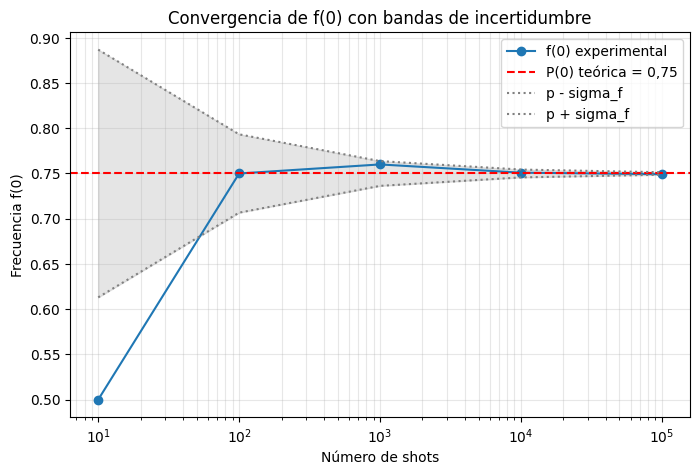

In [14]:
# --- INCERTIDUMBRE ESTADÍSTICA --- #
p = 0.75

sigma_f = []
for shot in shots_estudiados:
    sigma = np.sqrt(p * (1 - p) / shot)
    sigma_f.append(sigma)
    print(f"Shots: {shot:>7} | sigma_f: {sigma:.5f}")

sigma_f = np.array(sigma_f)

plt.figure(figsize=(8, 5))
plt.plot(shots_estudiados, frecuencias_0, marker="o", label="f(0) experimental")
plt.axhline(p, color="red", linestyle="--", label="P(0) teórica = 0,75")
plt.plot(shots_estudiados, p - sigma_f, color="gray", linestyle=":", label="p - sigma_f")
plt.plot(shots_estudiados, p + sigma_f, color="gray", linestyle=":", label="p + sigma_f")
plt.fill_between(shots_estudiados, p - sigma_f, p + sigma_f, color="gray", alpha=0.2)
plt.xscale("log")
plt.title("Convergencia de f(0) con bandas de incertidumbre")
plt.xlabel("Número de shots")
plt.ylabel("Frecuencia f(0)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

**Responde:**

1. ¿Cómo varía la incertidumbre con $N$?

Disminuye con la raíz cuadrada de $N$, ya que $\sigma_f\propto\frac{1}{\sqrt{N}}$. Por ejemplo, para $p=0{,}75$ pasa de $0{,}137$ con 10 shots a $0{,}0014$ con 100.000.

2. ¿Cuántos shots hacen falta aproximadamente para reducirla a la mitad?

Cuatro veces más, porque $\sigma_f(4N)=\sqrt{\frac{p(1-p)}{4N}}=\frac{\sigma_f(N)}{2}$.

3. ¿Por qué aumentar shots presenta rendimiento decreciente?

Porque para ganar la misma mejora relativa hay que multiplicar el número de shots, no sumarlo. Pasar de 10 a 100 shots (90 más) divide la incertidumbre entre 3, pero para volver a dividirla entre 3 necesitamos casi 900 más, y así sucesivamente. El coste crece mucho más rápido que la precisión que ganamos.

## Pruebas mínimas

Ejecuta estas pruebas después de completar las funciones y añade las necesarias para comprobar entradas no válidas.

In [15]:
# --- PRUEBAS MÍNIMAS --- #
assert isValidState([1, 0])[0]
assert isValidState([0, 1])[0]
assert not isValidState([1, 1])[0]
assert not isValidState([0, 0])[0]
assert not isValidState([1, 0, 0])[0]
assert np.isclose(np.linalg.norm(normalizeState([1, 1])[1]), 1.0)
assert np.isclose(sum(calculateProbs(psi_2)[1]), 1.0)
assert measure(psi_1, np.random.default_rng(42)) in (0, 1)
assert sum(recursiveMeasure(psi_2, 1000, 42).values()) == 1000

# --- PRUEBAS DE ENTRADAS NO VÁLIDAS Y CASOS LÍMITE --- #

# Estados no válidos.
assert not isValidState([np.nan, 0])[0]
assert not isValidState([np.inf, 0])[0]
assert not isValidState("abc")[0]
assert not isValidState([[1, 0], [0, 1]])[0]
assert not isNormalizedState([1, 1])
assert isNormalizedState([1j, 0])

# Normalización.
assert not normalizeState([0, 0])[0]
assert not normalizeState([1, 0, 0])[0]
assert not normalizeState([np.nan, 1])[0]
assert np.allclose(normalizeState([3, 4])[1], [0.6, 0.8])

# Probabilidades.
assert not calculateProbs([0, 0])[0]
assert np.allclose(calculateProbs(ket_0)[1], [1, 0])
assert np.allclose(calculateProbs(psi_4)[1], [0.5, 0.5])

# Medidas.
assert measure(ket_0, np.random.default_rng(1)) == 0
assert measure(ket_1, np.random.default_rng(1)) == 1
assert measure([0, 0])[0] is False
assert recursiveMeasure(ket_0, 100) == {0: 100, 1: 0}
assert recursiveMeasure(ket_1, 100) == {0: 0, 1: 100}

# Shots no válidos.
for shots_malos in [0, -5, 2.5, "10", None, True]:
    assert recursiveMeasure(psi_2, shots_malos)[0] is False

# Reproducibilidad con la misma semilla.
assert recursiveMeasure(psi_2, 1000, 42) == recursiveMeasure(psi_2, 1000, 42)

# Construcción de estados.
assert np.isclose(np.linalg.norm(createState(1 + 2j, 3 - 1j)[1]), 1.0)
assert not createState(0, 0)[0]
assert not createState(np.inf, 1)[0]
assert not createState("a", 1)[0]

print("Todas las pruebas se han ejecutado correctamente.")

Todas las pruebas se han ejecutado correctamente.


## Conclusiones

Redacta un máximo de 200 palabras respondiendo:

1. ¿Qué diferencia existe entre amplitud y probabilidad?
2. ¿Qué relación existe entre shots, frecuencias y probabilidades?
3. ¿Por qué una sola medida no permite reconstruir el estado?
4. ¿Por qué dos estados diferentes pueden producir el mismo histograma?
5. ¿Qué diferencia conceptual existe entre una superposición y una mezcla clásica?

**Conclusión:**

1. La amplitud es un número complejo que describe el estado, mientras que la probabilidad es el módulo al cuadrado de la amplitud (regla de Born), por lo que siempre es un número real entre 0 y 1.

2. Cada shot es una nueva preparación y medida del mismo estado. Las frecuencias son una estimación de las probabilidades, y se acercan a ellas al aumentar los shots, con un error que disminuye como $1/\sqrt{N}$.

3. Porque una medida solo devuelve un 0 o un 1 y además colapsa el estado, así que un único resultado no nos da información de $\alpha$ y $\beta$.

4. Porque el histograma solo recoge los módulos al cuadrado de las amplitudes, y la fase relativa no aparece. Por ejemplo, $|\psi_A\rangle$, $|\psi_B\rangle$ y $|\psi_C\rangle$ dan todos $P(0)=P(1)=0{,}5$.

5. En una superposición el qubit está en un único estado con amplitudes coherentes, y su fase relativa produce interferencia. En una mezcla clásica el estado es uno de varios y solo desconocemos cuál, por lo que se suman probabilidades sin fases ni interferencia.

## Lista de comprobación antes de entregar

- [ ] Todas las celdas se ejecutan en orden sin errores.
- [ ] No quedan bloques `TODO` sin completar.
- [ ] Las probabilidades suman uno.
- [ ] Las gráficas tienen títulos, etiquetas y leyendas.
- [ ] Las respuestas justifican los resultados.
- [ ] Las pruebas mínimas se ejecutan correctamente.
- [ ] El notebook conserva las salidas antes de la entrega.